<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE

# Load the dataset
df = pd.read_csv("csv_mindex.csv")
print(df)


  key1 key2  value1  value2
0  one    a       1       2
1  one    b       3       4
2  one    c       5       6
3  one    d       7       8
4  two    a       9      10
5  two    b      11      12
6  two    c      13      14
7  two    d      15      16


In [11]:
df.head()        # first 5 rows
df.info()        # structure
df.describe()    # statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key1    8 non-null      object
 1   key2    8 non-null      object
 2   value1  8 non-null      int64 
 3   value2  8 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 388.0+ bytes


,value1,value2
count,8.000000,8.000000
mean,8.000000,9.000000
std,4.898979,4.898979
min,1.000000,2.000000
25%,4.500000,5.500000
50%,8.000000,9.000000
75%,11.500000,12.500000
max,15.000000,16.000000


In [12]:
# Handling missing values
df.isnull().sum()


,0
key1,0
key2,0
value1,0
value2,0


In [13]:
#One-Hot Encoding (Categorical Variables)
df = pd.get_dummies(df, drop_first=True)



In [17]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)



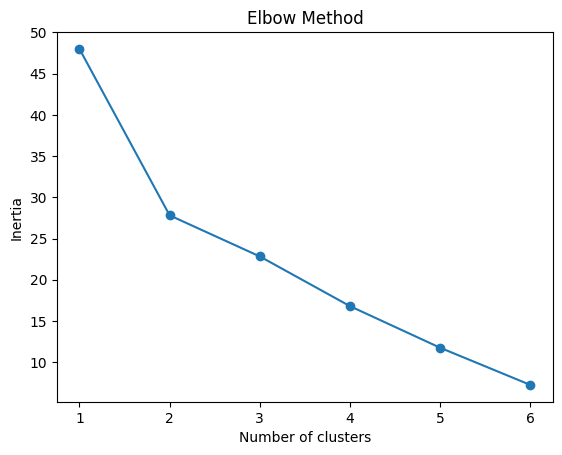

In [18]:
# Clustering

inertia = []

for k in range(1, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1, 7), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [19]:
# Applying K-means Clustering

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


In [20]:
#Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", score)


K-Means Silhouette Score: 0.24864324233664042


In [21]:
#Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=2)
hc_labels = hc.fit_predict(X_scaled)


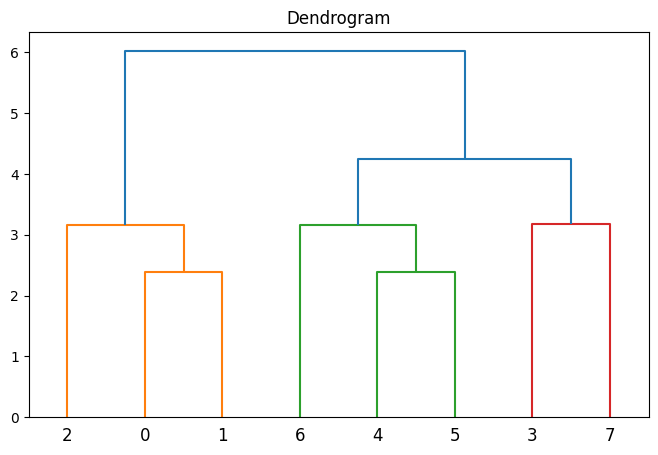

In [22]:
# Justfy clusters with dedogram
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()


In [23]:
# Silhouette
score_hc = silhouette_score(X_scaled, hc_labels)
print("Hierarchical Silhouette Score:", score_hc)


Hierarchical Silhouette Score: 0.2154062323106199


In [24]:
#Dimensionality Reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


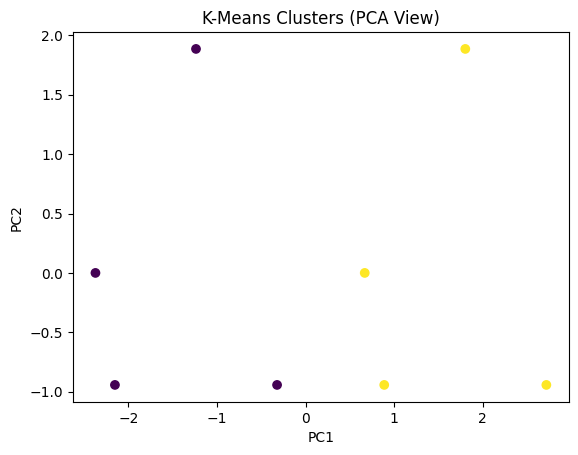

In [25]:
#Kmeans visualization
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


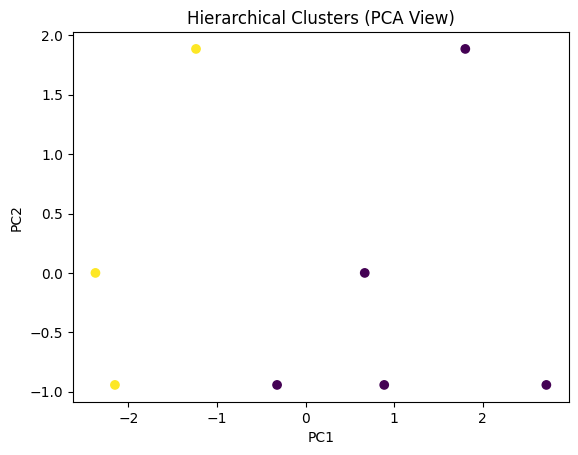

In [28]:
#Visualize PCA (Hierarchical Clusters)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hc_labels)
plt.title("Hierarchical Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


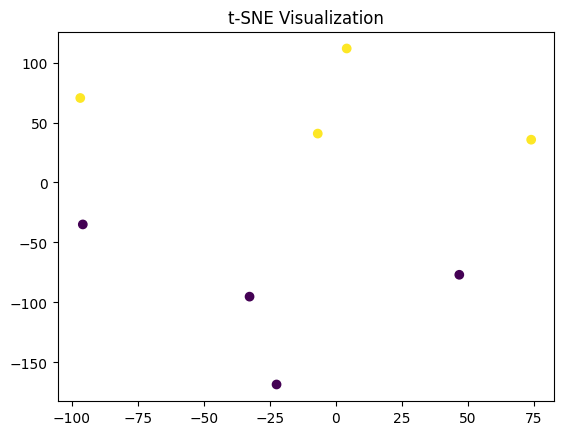

In [37]:
#t-SNE Visualization
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels)
plt.title("t-SNE Visualization")
plt.show()